In [1]:
!pip -q install datasets tokenizers sentencepiece pandas numpy matplotlib tqdm

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFKC
from tokenizers.processors import TemplateProcessing
from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)

In [3]:
LANGUAGE = "gujarati"

In [4]:
print("Selected language:", LANGUAGE)

Selected language: gujarati


In [12]:
from datasets import load_dataset

dataset = load_dataset(
    "ai4bharat/IndicCorpV2",
    "indiccorp_v2",
    split="guj_Gujr",
    streaming=True
)

print(dataset)

IterableDataset({
    features: Unknown,
    num_shards: 1
})


In [13]:
sample = next(iter(dataset))

print(sample)
print("\nColumns:", sample.keys())

{'text': 'આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ'}

Columns: dict_keys(['text'])


In [14]:
import re

def sentence_tokenize(text):
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)

    # Gujarati danda, double danda, and normal punctuation
    sentences = re.split(
        r'(?<=[।!?])\s+|(?<=[.!?])\s+',
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if len(s.strip()) > 5
    ]

    return sentences

# Test sentence tokenizer
print(sentence_tokenize(sample["text"]))

['આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ']


In [15]:
from tqdm.auto import tqdm

TARGET_SENTENCES = 1_102_000

sentences = []

for row in tqdm(dataset, desc="Collecting Gujarati sentences"):
    text = row["text"]

    new_sentences = sentence_tokenize(text)
    sentences.extend(new_sentences)

    if len(sentences) >= TARGET_SENTENCES:
        break

print("\nTotal sentences collected:", len(sentences))


Total sentences collected: 1102004


In [16]:
sentences = list(dict.fromkeys(sentences))

print("Unique sentences:", len(sentences))

Unique sentences: 1090718


In [17]:
print("First 10 sentences:\n")

for i, sentence in enumerate(sentences[:10]):
    print(f"{i+1}. {sentence}")

First 10 sentences:

1. આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ
2. મિથેનોલ આવ્યો ક્યાંથી?
3. આખરે ત્રણ રાજ્યોમાં મળેલ હાર પર કોંગ્રેસ અધ્યક્ષ રાહુલ ગાંધી દ્વારા પ્રથમ પ્રતિક્રિયા આપવામાં આવી છે.
4. તેમણે કહ્યું કે, ત્રિપુરા, નાગાલેન્ડ અને મેઘાલયમાં લોકોના જનાદેશનો સ્વાગત કરીએ છે અને આ ક્ષેત્રના લોકોનો વિશ્વાસ ફરીથી જીતીવા માટે પ્રતિબદ્ધ છીએ.
5. આ આંકડો માટે, અને વજન ઘટાડવા માટે પ્રકાશનનો દિવસ વિતાવવો ઉપયોગી છે, ઉદાહરણ તરીકે, અઠવાડિયામાં એક વખત.
6. તમારા માટે એક વિકલ્પ પસંદ કરો જે અગવડતાને કારણે નહીં કરે.
7. સૌથી વધુ લોકપ્રિય કીફિર પર અનલોડ છે.
8. આ ઠેકાઓ પરથી લીમડી તેમજ ઝાલોદના બૂટલેગરો વિદેશી દારૃનો મોટાપાયે જથ્થો ખરીદી મહિસાગર, હાલોલ, ગોધરા, આણંદ, નડિયાદ અને વડોદરા શહેર-જિલ્લામાં ઠાલવે છે.
9. આબુથી આવતો દારૃનો જથ્થો સાંચોર તેમજ પાલનપુર થઈ મહેસાણામાં રીટા અને વિરસિંહને ત્યાં ઉતારવામાં આવે છે, જ્યાંથી અમદાવાદ તેમજ ઉત્તર ગુજરાતમાં દારૃ સપ્લાઈ થાય છે.
10. રાજસ્થાનના બિચ્છુવાડાથી શામળાજી બોર્ડર થઈ હિંમતનગર, ગાંધીનગર અને અમદાવાદમાં બૂટલેગર સુનિલ, વિનોદ, દિલીપ અને રબારી દ્વાર

In [18]:
import numpy as np

sentence_lengths = np.array([
    len(sentence.split())
    for sentence in sentences
])

print("Minimum length:", sentence_lengths.min())
print("Maximum length:", sentence_lengths.max())
print("Average length:", round(sentence_lengths.mean(), 2))
print("Median length:", np.median(sentence_lengths))

Minimum length: 1
Maximum length: 1051
Average length: 14.99
Median length: 13.0


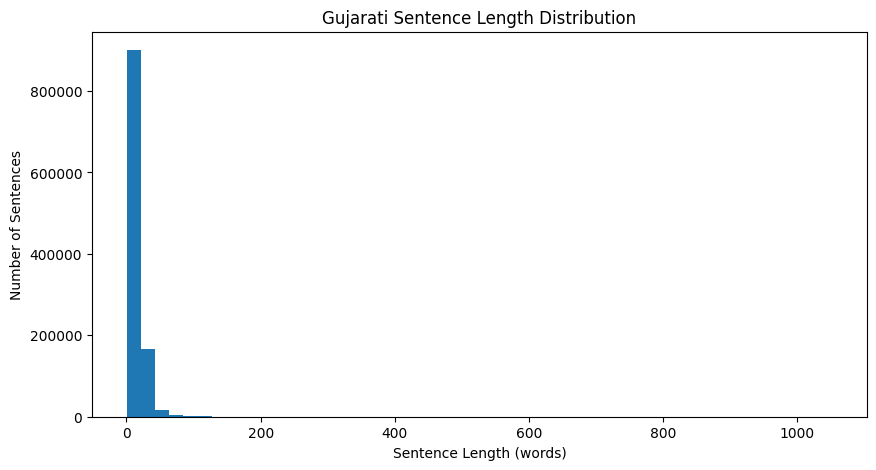

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(sentence_lengths, bins=50)

plt.xlabel("Sentence Length (words)")
plt.ylabel("Number of Sentences")
plt.title("Gujarati Sentence Length Distribution")

plt.show()

In [20]:
# Create sentence-length groups

def get_length_group(length):
    if length <= 5:
        return "1-5"
    elif length <= 10:
        return "6-10"
    elif length <= 20:
        return "11-20"
    elif length <= 30:
        return "21-30"
    elif length <= 50:
        return "31-50"
    else:
        return "51+"

length_groups = [
    get_length_group(length)
    for length in sentence_lengths
]

from collections import Counter

print(Counter(length_groups))

Counter({'11-20': 469173, '6-10': 306810, '21-30': 147732, '1-5': 100186, '31-50': 53831, '51+': 12986})


In [21]:
import random

random.seed(42)

# Store indices according to sentence-length group
groups = {}

for i, group in enumerate(length_groups):
    groups.setdefault(group, []).append(i)

dev_indices = []
test_indices = []

# Select sentences from every length group
for group, indices in groups.items():
    random.shuffle(indices)

    # Proportional selection
    n = max(2, int(2000 * len(indices) / len(sentences)))

    dev_indices.extend(indices[:n])
    test_indices.extend(indices[n:2*n])

# Shuffle
random.shuffle(dev_indices)
random.shuffle(test_indices)

# Exactly 1000 each
dev_indices = dev_indices[:1000]
test_indices = test_indices[:1000]

# Make sure there is no overlap
dev_set = set(dev_indices)
test_indices = [i for i in test_indices if i not in dev_set]

# Fill test set if necessary
used = set(dev_indices + test_indices)

remaining = [
    i for i in range(len(sentences))
    if i not in used
]

random.shuffle(remaining)

while len(test_indices) < 1000:
    test_indices.append(remaining.pop())

dev_sentences = [sentences[i] for i in dev_indices]
test_sentences = [sentences[i] for i in test_indices]

print("Development sentences:", len(dev_sentences))
print("Test sentences:", len(test_sentences))

Development sentences: 1000
Test sentences: 1000


In [22]:
held_out = set(dev_indices + test_indices)

training_sentences = [
    sentence
    for i, sentence in enumerate(sentences)
    if i not in held_out
]

print("Available training sentences:", len(training_sentences))

Available training sentences: 1088718


In [23]:
dev_lengths = [len(s.split()) for s in dev_sentences]
test_lengths = [len(s.split()) for s in test_sentences]

print("Development set")
print("Average length:", round(np.mean(dev_lengths), 2))
print("Median length:", np.median(dev_lengths))

print("\nTest set")
print("Average length:", round(np.mean(test_lengths), 2))
print("Median length:", np.median(test_lengths))

Development set
Average length: 15.04
Median length: 13.0

Test set
Average length: 15.38
Median length: 13.0


In [24]:
from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFKC

In [46]:
def train_bpe(train_data, vocab_size):

    tokenizer = Tokenizer(
        BPE(unk_token="[UNK]")
    )

    tokenizer.normalizer = NFKC()
    tokenizer.pre_tokenizer = Whitespace()

    trainer = BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=[
            "[UNK]",
            "[PAD]",
            "[CLS]",
            "[SEP]",
            "[MASK]"
        ]
    )

    tokenizer.train_from_iterator(
        train_data,
        trainer=trainer
    )

    return tokenizer

In [47]:
def train_wordpiece(train_data, vocab_size):

    tokenizer = Tokenizer(
        WordPiece(unk_token="[UNK]")
    )

    tokenizer.normalizer = NFKC()
    tokenizer.pre_tokenizer = Whitespace()

    trainer = WordPieceTrainer(
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=[
            "[UNK]",
            "[PAD]",
            "[CLS]",
            "[SEP]",
            "[MASK]"
        ]
    )

    tokenizer.train_from_iterator(
        train_data,
        trainer=trainer
    )

    return tokenizer

In [48]:
def evaluate_tokenizer(tokenizer, data):

    total_tokens = 0
    total_words = 0

    token_counts = []

    for sentence in data:

        encoding = tokenizer.encode(sentence)

        tokens = len(encoding.tokens)
        words = len(sentence.split())

        total_tokens += tokens
        total_words += words

        token_counts.append(tokens)

    return {
        "total_tokens": total_tokens,
        "avg_tokens_per_sentence": total_tokens / len(data),
        "avg_tokens_per_word": total_tokens / total_words
    }

In [49]:
bpe_test = train_bpe(
    training_sentences[:100000],
    20000
)

encoded = bpe_test.encode(dev_sentences[0])

print("Original:")
print(dev_sentences[0])

print("\nBPE Tokens:")
print(encoded.tokens)

print("\nNumber of tokens:", len(encoded.tokens))

Original:
નિયુક્તિને સમર્થન આપવા માટે સેનેટની ન્યાયિક સમિતિમાં યોજાયેલી સુનાવણી વખતે સભ્યોને તેમણે જણાવ્યું હતું કે આપણે ખુલ્લા વિશ્વમાં રહેતા હોવાનો વિચાર સંપૂર્ણપણે ખોટો છે.

BPE Tokens:
['નિયુક્તિ', 'ને', 'સમર્થન', 'આપવા', 'માટે', 'સેનેટ', 'ની', 'ન્યાયિક', 'સમિતિમાં', 'યોજાયેલી', 'સુનાવણી', 'વખતે', 'સભ્યોને', 'તેમણે', 'જણાવ્યું', 'હતું', 'કે', 'આપણે', 'ખુલ્લા', 'વિશ્વમાં', 'રહેતા', 'હોવાનો', 'વિચાર', 'સંપૂર્ણપણે', 'ખોટો', 'છે', '.']

Number of tokens: 27


In [50]:
wp_test = train_wordpiece(
    training_sentences[:100000],
    20000
)

encoded = wp_test.encode(dev_sentences[0])

print("Original:")
print(dev_sentences[0])

print("\nWordPiece Tokens:")
print(encoded.tokens)

print("\nNumber of tokens:", len(encoded.tokens))

Original:
નિયુક્તિને સમર્થન આપવા માટે સેનેટની ન્યાયિક સમિતિમાં યોજાયેલી સુનાવણી વખતે સભ્યોને તેમણે જણાવ્યું હતું કે આપણે ખુલ્લા વિશ્વમાં રહેતા હોવાનો વિચાર સંપૂર્ણપણે ખોટો છે.

WordPiece Tokens:
['નિયુક્ત', '##િને', 'સમર્થન', 'આપવા', 'માટે', 'સેનેટ', '##ની', 'ન્યાયિક', 'સમિતિમાં', 'યોજાયેલી', 'સુનાવણી', 'વખતે', 'સભ્યોને', 'તેમણે', 'જણાવ્યું', 'હતું', 'કે', 'આપણે', 'ખુલ્લા', 'વિશ્વમાં', 'રહેતા', 'હોવાનો', 'વિચાર', 'સંપૂર્ણપણે', 'ખોટો', 'છે', '.']

Number of tokens: 27


In [51]:
TRAINING_SIZES = [
    100000,
    300000,
    500000,
    1000000
]

VOCAB_SIZE = 30000

In [52]:
bpe_training_results = []

for size in TRAINING_SIZES:

    print("\n" + "="*60)
    print("BPE - Training Size:", size)
    print("="*60)

    train_data = training_sentences[:size]

    tokenizer = train_bpe(
        train_data,
        VOCAB_SIZE
    )

    result = evaluate_tokenizer(
        tokenizer,
        dev_sentences
    )

    result["training_size"] = size
    result["tokenizer"] = "BPE"

    bpe_training_results.append(result)

    print(result)


BPE - Training Size: 100000
{'total_tokens': 19646, 'avg_tokens_per_sentence': 19.646, 'avg_tokens_per_word': 1.3065974993349294, 'training_size': 100000, 'tokenizer': 'BPE'}

BPE - Training Size: 300000
{'total_tokens': 19542, 'avg_tokens_per_sentence': 19.542, 'avg_tokens_per_word': 1.299680766161213, 'training_size': 300000, 'tokenizer': 'BPE'}

BPE - Training Size: 500000
{'total_tokens': 19565, 'avg_tokens_per_sentence': 19.565, 'avg_tokens_per_word': 1.3012104283054005, 'training_size': 500000, 'tokenizer': 'BPE'}

BPE - Training Size: 1000000
{'total_tokens': 19551, 'avg_tokens_per_sentence': 19.551, 'avg_tokens_per_word': 1.3002793296089385, 'training_size': 1000000, 'tokenizer': 'BPE'}


In [53]:
wp_training_results = []

for size in TRAINING_SIZES:

    print("\n" + "="*60)
    print("WordPiece - Training Size:", size)
    print("="*60)

    train_data = training_sentences[:size]

    tokenizer = train_wordpiece(
        train_data,
        VOCAB_SIZE
    )

    result = evaluate_tokenizer(
        tokenizer,
        dev_sentences
    )

    result["training_size"] = size
    result["tokenizer"] = "WordPiece"

    wp_training_results.append(result)

    print(result)


WordPiece - Training Size: 100000
{'total_tokens': 19954, 'avg_tokens_per_sentence': 19.954, 'avg_tokens_per_word': 1.3270816706570896, 'training_size': 100000, 'tokenizer': 'WordPiece'}

WordPiece - Training Size: 300000
{'total_tokens': 19890, 'avg_tokens_per_sentence': 19.89, 'avg_tokens_per_word': 1.3228252194732641, 'training_size': 300000, 'tokenizer': 'WordPiece'}

WordPiece - Training Size: 500000
{'total_tokens': 19886, 'avg_tokens_per_sentence': 19.886, 'avg_tokens_per_word': 1.3225591912742751, 'training_size': 500000, 'tokenizer': 'WordPiece'}

WordPiece - Training Size: 1000000
{'total_tokens': 19899, 'avg_tokens_per_sentence': 19.899, 'avg_tokens_per_word': 1.3234237829209896, 'training_size': 1000000, 'tokenizer': 'WordPiece'}


In [54]:
training_results = pd.DataFrame(
    bpe_training_results + wp_training_results
)

display(training_results)

,total_tokens,avg_tokens_per_sentence,avg_tokens_per_word,training_size,tokenizer
0,19646,19.646,1.306597,100000,BPE
1,19542,19.542,1.299681,300000,BPE
2,19565,19.565,1.301210,500000,BPE
3,19551,19.551,1.300279,1000000,BPE
4,19954,19.954,1.327082,100000,WordPiece
5,19890,19.890,1.322825,300000,WordPiece
6,19886,19.886,1.322559,500000,WordPiece
7,19899,19.899,1.323424,1000000,WordPiece


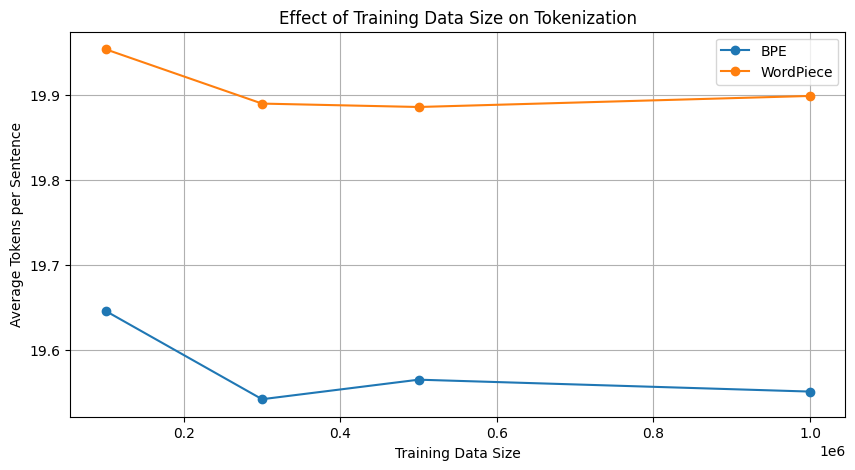

In [55]:
plt.figure(figsize=(10, 5))

for name in ["BPE", "WordPiece"]:

    data = training_results[
        training_results["tokenizer"] == name
    ]

    plt.plot(
        data["training_size"],
        data["avg_tokens_per_sentence"],
        marker="o",
        label=name
    )

plt.xlabel("Training Data Size")
plt.ylabel("Average Tokens per Sentence")
plt.title("Effect of Training Data Size on Tokenization")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
VOCAB_SIZES = [
    20000,
    30000,
    50000
]

TRAIN_SIZE = 1000000

train_data = training_sentences[:TRAIN_SIZE]

In [57]:
bpe_vocab_results = []

for vocab_size in VOCAB_SIZES:

    print("\n" + "="*60)
    print("BPE - Vocabulary Size:", vocab_size)
    print("="*60)

    tokenizer = train_bpe(
        train_data,
        vocab_size
    )

    result = evaluate_tokenizer(
        tokenizer,
        dev_sentences
    )

    result["vocab_size"] = vocab_size
    result["tokenizer"] = "BPE"

    bpe_vocab_results.append(result)

    print(result)


BPE - Vocabulary Size: 20000
{'total_tokens': 20459, 'avg_tokens_per_sentence': 20.459, 'avg_tokens_per_word': 1.3606677307794626, 'vocab_size': 20000, 'tokenizer': 'BPE'}

BPE - Vocabulary Size: 30000
{'total_tokens': 19551, 'avg_tokens_per_sentence': 19.551, 'avg_tokens_per_word': 1.3002793296089385, 'vocab_size': 30000, 'tokenizer': 'BPE'}

BPE - Vocabulary Size: 50000
{'total_tokens': 18760, 'avg_tokens_per_sentence': 18.76, 'avg_tokens_per_word': 1.2476722532588453, 'vocab_size': 50000, 'tokenizer': 'BPE'}


In [58]:
wp_vocab_results = []

for vocab_size in VOCAB_SIZES:

    print("\n" + "="*60)
    print("WordPiece - Vocabulary Size:", vocab_size)
    print("="*60)

    tokenizer = train_wordpiece(
        train_data,
        vocab_size
    )

    result = evaluate_tokenizer(
        tokenizer,
        dev_sentences
    )

    result["vocab_size"] = vocab_size
    result["tokenizer"] = "WordPiece"

    wp_vocab_results.append(result)

    print(result)


WordPiece - Vocabulary Size: 20000
{'total_tokens': 20900, 'avg_tokens_per_sentence': 20.9, 'avg_tokens_per_word': 1.38999733971801, 'vocab_size': 20000, 'tokenizer': 'WordPiece'}

WordPiece - Vocabulary Size: 30000
{'total_tokens': 19899, 'avg_tokens_per_sentence': 19.899, 'avg_tokens_per_word': 1.3234237829209896, 'vocab_size': 30000, 'tokenizer': 'WordPiece'}

WordPiece - Vocabulary Size: 50000
{'total_tokens': 18979, 'avg_tokens_per_sentence': 18.979, 'avg_tokens_per_word': 1.2622372971534983, 'vocab_size': 50000, 'tokenizer': 'WordPiece'}


In [38]:
vocab_results = pd.DataFrame(
    bpe_vocab_results + wp_vocab_results
)

display(vocab_results)

,total_tokens,avg_tokens_per_sentence,avg_tokens_per_word,vocab_size,tokenizer
0,20459,20.459,1.360668,20000,BPE
1,19551,19.551,1.300279,30000,BPE
2,18760,18.760,1.247672,50000,BPE
3,20900,20.900,1.389997,20000,WordPiece
4,19899,19.899,1.323424,30000,WordPiece
5,18979,18.979,1.262237,50000,WordPiece


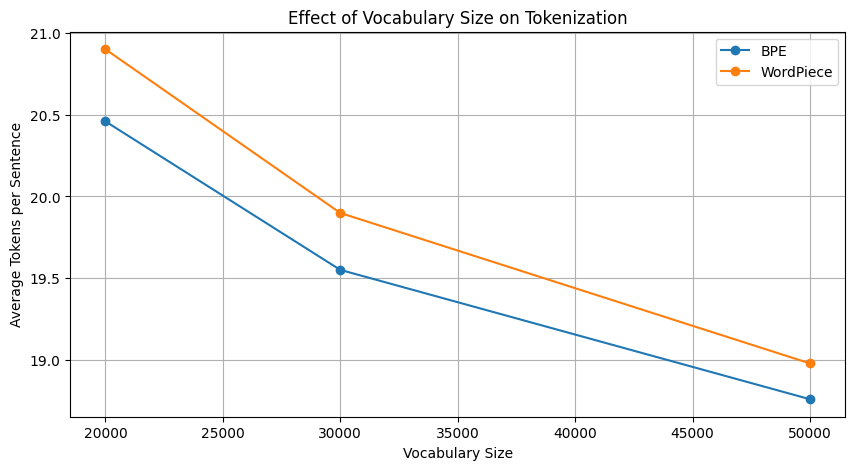

In [59]:
plt.figure(figsize=(10, 5))

for name in ["BPE", "WordPiece"]:

    data = vocab_results[
        vocab_results["tokenizer"] == name
    ]

    plt.plot(
        data["vocab_size"],
        data["avg_tokens_per_sentence"],
        marker="o",
        label=name
    )

plt.xlabel("Vocabulary Size")
plt.ylabel("Average Tokens per Sentence")
plt.title("Effect of Vocabulary Size on Tokenization")
plt.legend()
plt.grid(True)

plt.show()

In [60]:
final_bpe = train_bpe(
    training_sentences[:1000000],
    30000
)

final_wordpiece = train_wordpiece(
    training_sentences[:1000000],
    30000
)

print("Final tokenizers trained.")

Final tokenizers trained.


In [61]:
bpe_test_result = evaluate_tokenizer(
    final_bpe,
    test_sentences
)

print("BPE Test Results:")
print(bpe_test_result)

BPE Test Results:
{'total_tokens': 20137, 'avg_tokens_per_sentence': 20.137, 'avg_tokens_per_word': 1.3096383975026014}


In [62]:
wp_test_result = evaluate_tokenizer(
    final_wordpiece,
    test_sentences
)

print("WordPiece Test Results:")
print(wp_test_result)

WordPiece Test Results:
{'total_tokens': 20450, 'avg_tokens_per_sentence': 20.45, 'avg_tokens_per_word': 1.3299947970863684}


In [63]:
final_comparison = pd.DataFrame([
    {
        "Tokenizer": "BPE",
        **bpe_test_result
    },
    {
        "Tokenizer": "WordPiece",
        **wp_test_result
    }
])

display(final_comparison)

,Tokenizer,total_tokens,avg_tokens_per_sentence,avg_tokens_per_word
0,BPE,20137,20.137,1.309638
1,WordPiece,20450,20.450,1.329995


In [64]:
for i, sentence in enumerate(test_sentences[:5]):

    print("\n" + "="*80)
    print("Example", i + 1)

    print("\nOriginal:")
    print(sentence)

    print("\nBPE:")
    print(final_bpe.encode(sentence).tokens)

    print("\nWordPiece:")
    print(final_wordpiece.encode(sentence).tokens)


Example 1

Original:
વાસ્તવમાં, શૈલી ગતિશીલ લગભગ પોતની દ્રષ્ટિએ વર્ણન કરી શકાય છે.

BPE:
['વાસ્તવમાં', ',', 'શૈલી', 'ગતિશીલ', 'લગભગ', 'પો', 'તની', 'દ્રષ્ટિએ', 'વર્ણન', 'કરી', 'શકાય', 'છે', '.']

WordPiece:
['વાસ્તવમાં', ',', 'શૈલી', 'ગતિશીલ', 'લગભગ', 'પોત', '##ની', 'દ્રષ્ટિએ', 'વર્ણન', 'કરી', 'શકાય', 'છે', '.']

Example 2

Original:
તેના સૌંદર્યલક્ષી લક્ષણો ઉપરાંત, આ ભાગ અદભૂત છે કારણ કે તે હૉલી -વેક્સ કાસ્ટિંગ પ્રક્રિયાનો ઉપયોગ કરવા માટે જાણીતી સૌથી જૂની હોલો-કાસ્ટ શિલ્પ વસ્તુ છે.

BPE:
['તેના', 'સૌંદર્ય', 'લક્ષી', 'લક્ષણો', 'ઉપરાંત', ',', 'આ', 'ભાગ', 'અદભૂત', 'છે', 'કારણ', 'કે', 'તે', 'હૉ', 'લી', '-', 'વે', 'ક્સ', 'કાસ્ટિંગ', 'પ્રક્રિયાનો', 'ઉપયોગ', 'કરવા', 'માટે', 'જાણીતી', 'સૌથી', 'જૂની', 'હો', 'લો', '-', 'કાસ્ટ', 'શિલ્પ', 'વસ્તુ', 'છે', '.']

WordPiece:
['તેના', 'સૌંદર્ય', '##લક્ષી', 'લક્ષણો', 'ઉપરાંત', ',', 'આ', 'ભાગ', 'અદભૂત', 'છે', 'કારણ', 'કે', 'તે', 'હૉ', '##લી', '-', 'વેક્સ', 'કાસ્ટિંગ', 'પ્રક્રિયાનો', 'ઉપયોગ', 'કરવા', 'માટે', 'જાણીતી', 'સૌથી', 'જૂની', 'હોલ', '##ો', '-', 'ક

In [66]:
training_results.to_csv(
    "training_size_results.csv",
    index=False
)

vocab_results.to_csv(
    "vocabulary_size_results.csv",
    index=False
)

final_comparison.to_csv(
    "final_test_results.csv",
    index=False
)

pd.DataFrame({
    "text": dev_sentences
}).to_csv(
    "development_1000.csv",
    index=False
)

pd.DataFrame({
    "text": test_sentences
}).to_csv(
    "test_1000.csv",
    index=False
)

print("All results and datasets saved successfully.")

All results and datasets saved successfully.
